# 多因子构建与回归分析（新建）

本 Notebook 构建并分析以下因子：
- 市场（Market）
- 规模（Size）
- 价值（Value）
- 股息率（Dividend Yield）
- 流动性（换手率，Liquidity）
- 动量（Momentum）

分析内容包含：
1. 因子构建与清洗（对齐、去极值、标准化）
2. 截面回归（Fama-MacBeth 思路）
3. 时序回归（多因子模型）
4. 因子相关性与可视化
5. 结果导出

## 1) 数据读取与环境配置

- 导入依赖库
- 从 DuckDB 读取个股日频面板（收益率、市值、PB、股息率、换手率、上市日期）
- 从 DuckDB 读取沪深300指数收益作为市场基准
- 股票池使用全市场股票，但剔除上市后 1 个月内样本
- 统一日期与股票代码

In [54]:
import numpy as np
import pandas as pd
import duckdb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

BASE_DIR = Path('.')
DB_PATH = BASE_DIR / 'trading_data.duckdb'

print('DB exists:', DB_PATH.exists())

DB exists: True


In [55]:
stock_sql = '''
SELECT
    trade_date,
    stock_code,
    list_date,
    change_pct,
    total_mkt_cap,
    pb,
    dividend_yield_pct,
    turnover_pct
FROM trading_data_clean
WHERE trade_date IS NOT NULL
  AND stock_code IS NOT NULL
'''

index_sql = '''
SELECT
    trade_date,
    stock_code,
    change_pct,
    close,
    prev_close
FROM trading_data_clean
WHERE stock_code = '000300.SH'
  AND trade_date IS NOT NULL
'''

with duckdb.connect(str(DB_PATH), read_only=True) as con:
    raw_df = con.execute(stock_sql).fetchdf()
    index_raw = con.execute(index_sql).fetchdf()


def normalize_stock_code(code):
    if pd.isna(code):
        return np.nan
    s = str(code).strip()
    if s == '' or s.lower() == 'nan':
        return np.nan

    if '.' in s:
        base, suffix = s.split('.', 1)
        digits = ''.join(ch for ch in base if ch.isdigit())
        base_norm = digits.zfill(6) if digits else base
        return f"{base_norm}.{suffix.upper()}"

    digits = ''.join(ch for ch in s if ch.isdigit())
    if digits:
        return digits.zfill(6)
    return s


# 个股数据：日期与类型清洗 + stock_code 补前导 0
raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'])
raw_df['list_date'] = pd.to_datetime(raw_df['list_date'], errors='coerce')
raw_df['stock_code'] = raw_df['stock_code'].apply(normalize_stock_code)
for c in ['change_pct', 'total_mkt_cap', 'pb', 'dividend_yield_pct', 'turnover_pct']:
    raw_df[c] = pd.to_numeric(raw_df[c], errors='coerce')
raw_df['ret'] = raw_df['change_pct'] / 100.0

# 指数数据：直接来自 DuckDB 的 000300.SH
index_raw['trade_date'] = pd.to_datetime(index_raw['trade_date'])
index_raw['stock_code'] = index_raw['stock_code'].apply(normalize_stock_code)
for c in ['change_pct', 'close', 'prev_close']:
    index_raw[c] = pd.to_numeric(index_raw[c], errors='coerce')

index_raw['hs300_ret'] = np.where(
    index_raw['change_pct'].notna(),
    index_raw['change_pct'] / 100.0,
    np.where(index_raw['prev_close'] > 0, index_raw['close'] / index_raw['prev_close'] - 1.0, np.nan)
)

index_df = (
    index_raw[['trade_date', 'hs300_ret']]
    .dropna(subset=['trade_date', 'hs300_ret'])
    .drop_duplicates('trade_date')
    .sort_values('trade_date')
    .reset_index(drop=True)
)

if index_df.empty:
    raise ValueError('000300.SH 指数序列为空，无法确定因子构建起始时间。')

# 全流程样本起点：对齐到 000300.SH 的起始交易日
analysis_start_date = index_df['trade_date'].min()

# 个股面板中剔除指数本身 + 截取统一起始日
index_code_set = {'000300.SH', '000300'}
df = raw_df.loc[~raw_df['stock_code'].isin(index_code_set)].copy()
df = df.loc[df['trade_date'] >= analysis_start_date].copy()

# 剔除新股：上市后 1 个月内不参与组合构建
df['eligible_date'] = df['list_date'] + pd.DateOffset(months=1)
new_stock_mask = df['eligible_date'].notna() & (df['trade_date'] < df['eligible_date'])
removed_new_stock_rows = int(new_stock_mask.sum())
df = df.loc[~new_stock_mask].copy()
df = df.drop(columns=['eligible_date'])

# 指数样本仅按起始日对齐，不受新股过滤影响
index_df = index_df.loc[index_df['trade_date'] >= analysis_start_date].copy()

print('analysis_start_date:', analysis_start_date)
print('stock panel shape (all stocks, new-listing filtered):', df.shape)
print('removed rows within 1 month after listing:', removed_new_stock_rows)
print('stocks with missing list_date:', int(df['list_date'].isna().sum()))
print('index shape:', index_df.shape)
print(df[['trade_date','stock_code','list_date','ret']].head(3))
print(index_df.head(3))

analysis_start_date: 2005-01-04 00:00:00
stock panel shape (all stocks, new-listing filtered): (13967069, 9)
removed rows within 1 month after listing: 238033
stocks with missing list_date: 24101
index shape: (5083, 2)
  trade_date stock_code  list_date       ret
0 2025-12-05     000001 1991-04-03  0.003481
1 2025-12-04     000001 1991-04-03 -0.005195
2 2025-12-03     000001 1991-04-03 -0.007732
  trade_date  hs300_ret
0 2005-01-04  -0.017206
1 2005-01-05   0.009941
2 2005-01-06  -0.009460


## 2) 收益率与基准（市场）因子构建

- 个股收益率：`ret = change_pct / 100`
- 目标收益：下一期收益 `next_ret`
- 市场因子：使用沪深300收益近似 $R_m-R_f$（本示例中暂设 $R_f=0$）

In [56]:
# 原地排序，避免大表 reset_index 引发额外内存拷贝
df.sort_values(['stock_code', 'trade_date'], inplace=True)

df['next_ret'] = df.groupby('stock_code', group_keys=False)['ret'].shift(-1)

# 动量信号：1月(20日)、3月(60日)、12月(240日)动量等权平均，跳过最近1日
K = 1
WIN_1M, WIN_3M, WIN_12M = 20, 60, 240

ret_shifted = df.groupby('stock_code', group_keys=False)['ret'].shift(K)
one_plus_ret = 1.0 + ret_shifted

df['mom_1m'] = (
    one_plus_ret.groupby(df['stock_code'])
    .rolling(WIN_1M)
    .apply(np.prod, raw=True)
    .reset_index(level=0, drop=True) - 1.0
)

df['mom_3m'] = (
    one_plus_ret.groupby(df['stock_code'])
    .rolling(WIN_3M)
    .apply(np.prod, raw=True)
    .reset_index(level=0, drop=True) - 1.0
)

df['mom_12m'] = (
    one_plus_ret.groupby(df['stock_code'])
    .rolling(WIN_12M)
    .apply(np.prod, raw=True)
    .reset_index(level=0, drop=True) - 1.0
)

df['mom_signal'] = df[['mom_1m', 'mom_3m', 'mom_12m']].mean(axis=1)

# 合并市场收益（作为 market 因子暴露输入）
if 'hs300_ret' in df.columns:
    df = df.drop(columns=['hs300_ret'])
df = df.merge(index_df, on='trade_date', how='left')
df['market_excess'] = df['hs300_ret']  # rf 设为 0

print(df[['trade_date','stock_code','ret','next_ret','mom_1m','mom_3m','mom_12m','mom_signal','market_excess']].head())

  trade_date stock_code     ret  next_ret  mom_1m  mom_3m  mom_12m  mom_signal  market_excess
0 2005-01-04     000001 -0.0106   -0.0092     NaN     NaN      NaN         NaN      -0.017206
1 2005-01-05     000001 -0.0092    0.0093     NaN     NaN      NaN         NaN       0.009941
2 2005-01-06     000001  0.0093   -0.0015     NaN     NaN      NaN         NaN      -0.009460
3 2005-01-07     000001 -0.0015    0.0123     NaN     NaN      NaN         NaN       0.000797
4 2005-01-10     000001  0.0123   -0.0091     NaN     NaN      NaN         NaN       0.010083


In [57]:
s_000002 = df.loc[df['stock_code'] == '000002', ['trade_date', 'ret', 'mom_signal']].copy()
print('rows:', len(s_000002))
print('ret non-null:', s_000002['ret'].notna().sum())
print('mom non-null:', s_000002['mom_signal'].notna().sum())
print(s_000002.head(30))
print(s_000002.tail(5))

rows: 4883
ret non-null: 4883
mom non-null: 4863
      trade_date     ret  mom_signal
10018 2005-01-04  0.0019         NaN
10019 2005-01-05  0.0361         NaN
10020 2005-01-06 -0.0055         NaN
10021 2005-01-07  0.0092         NaN
10022 2005-01-10 -0.0055         NaN
10023 2005-01-11  0.0110         NaN
10024 2005-01-12  0.0036         NaN
10025 2005-01-13  0.0072         NaN
10026 2005-01-14 -0.0180         NaN
10027 2005-01-17 -0.0055         NaN
10028 2005-01-18  0.0037         NaN
10029 2005-01-19 -0.0147         NaN
10030 2005-01-20  0.0074         NaN
10031 2005-01-21  0.0424         NaN
10032 2005-01-24  0.0195         NaN
10033 2005-01-25  0.0000         NaN
10034 2005-01-26 -0.0139         NaN
10035 2005-01-27 -0.0053         NaN
10036 2005-01-28  0.0018         NaN
10037 2005-01-31  0.0035         NaN
10038 2005-02-01  0.0053    0.079603
10039 2005-02-02  0.0438    0.083267
10040 2005-02-03 -0.0101    0.091317
10041 2005-02-04  0.0322    0.086270
10042 2005-02-16  0.0115  

## 3)-8) 规模/价值/股息率/流动性/动量因子构建 + 对齐标准化

- 规模：$-\log(\text{总市值})$
- 价值：$\log(1/\text{PB})$（仅 PB>0）
- 股息率：`dividend_yield_pct`
- 流动性：`turnover_pct`
- 动量：1月（20日）、3月（60日）、12月（240日）动量的等权平均（均跳过最近1日）
- 新增 BERT Long-Short 组合收益因子（来自 `backtest_compare_4way.csv` 的 `ret_finbert_base`，用于时序因子分析）
- 每日截面做 1%-99% 分位数截尾 + z-score 标准化

In [58]:
# 读取 BERT long-short 组合收益（来自 backtest 输出）
bert_factor_path = BASE_DIR / 'backtest_compare_4way.csv'
if not bert_factor_path.exists():
    raise FileNotFoundError(f'未找到 BERT 回测文件: {bert_factor_path}')

bert_df = pd.read_csv(bert_factor_path, usecols=['date', 'ret_finbert_base'])
bert_df['trade_date'] = pd.to_datetime(bert_df['date'])
bert_df['bert_ls_ret'] = pd.to_numeric(bert_df['ret_finbert_base'], errors='coerce')
bert_df = bert_df[['trade_date', 'bert_ls_ret']].dropna(subset=['trade_date']).drop_duplicates('trade_date')

# 将 BERT long-short 因子并入日频面板（按日期），支持重复运行
drop_cols = [c for c in ['bert_ls_ret', 'bert_ls_ret_x', 'bert_ls_ret_y'] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
df = df.merge(bert_df, on='trade_date', how='left')

# 原始截面因子暴露
df['size_raw'] = np.where(df['total_mkt_cap'] > 0, -np.log(df['total_mkt_cap']), np.nan)
df['value_raw'] = np.where(df['pb'] > 0, np.log(1.0 / df['pb']), np.nan)
df['dividend_raw'] = df['dividend_yield_pct']
df['liquidity_raw'] = df['turnover_pct']
df['momentum_raw'] = df['mom_signal']
df['market_raw'] = df['market_excess']

factor_raw_cols = ['market_raw', 'size_raw', 'value_raw', 'dividend_raw', 'liquidity_raw', 'momentum_raw']


def winsorize_by_date(series: pd.Series, lower=0.01, upper=0.99) -> pd.Series:
    if series.notna().sum() < 5:
        return series
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)


def zscore_by_date(series: pd.Series) -> pd.Series:
    mu = series.mean()
    sd = series.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return series * np.nan
    return (series - mu) / sd

for col in factor_raw_cols:
    w_col = col.replace('_raw', '_w')
    z_col = col.replace('_raw', '_z')
    df[w_col] = df.groupby('trade_date', group_keys=False)[col].transform(winsorize_by_date)
    df[z_col] = df.groupby('trade_date', group_keys=False)[w_col].transform(zscore_by_date)

factor_cols = ['market_z', 'size_z', 'value_z', 'dividend_z', 'liquidity_z', 'momentum_z']

model_df = df[['trade_date', 'stock_code', 'next_ret'] + factor_cols + ['bert_ls_ret']].copy()
model_df = model_df.dropna(subset=['next_ret'])

print('model_df shape:', model_df.shape)
print('bert factor date coverage:', model_df['bert_ls_ret'].notna().mean())
print(model_df.head())

model_df shape: (13937439, 10)
bert factor date coverage: 0.6441834830631367
  trade_date stock_code  next_ret  market_z    size_z   value_z  dividend_z  liquidity_z  momentum_z  bert_ls_ret
0 2005-01-04     000001   -0.0092       0.0 -2.482992 -0.646264   -0.670757    -0.659655         NaN          NaN
1 2005-01-05     000001    0.0093       0.0 -2.461215 -0.591913   -0.671202    -0.489102         NaN          NaN
2 2005-01-06     000001   -0.0015       0.0 -2.482208 -0.625816   -0.671735    -0.507759         NaN          NaN
3 2005-01-07     000001    0.0123       NaN -2.482366 -0.616441   -0.670271    -0.649892         NaN          NaN
4 2005-01-10     000001   -0.0091       0.0 -2.493133 -0.627056   -0.673600    -0.577016         NaN          NaN


## 9) 截面回归分析（Fama-MacBeth）

按日做截面回归：
$$
r_{i,t+1} = \alpha_t + \beta_t' f_{i,t} + \epsilon_{i,t+1}
$$
并汇总因子风险溢价的均值、波动、t 值和显著性。

In [59]:
min_obs = 50
results = []

for dt, g in model_df.groupby('trade_date'):
    d = g.dropna(subset=factor_cols + ['next_ret']).copy()
    if len(d) < min_obs:
        continue
    X = sm.add_constant(d[factor_cols], has_constant='add')
    y = d['next_ret']
    fit = sm.OLS(y, X).fit()

    row = {
        'trade_date': dt,
        'n_obs': int(fit.nobs),
        'r2': fit.rsquared,
        'alpha': fit.params.get('const', np.nan),
        'alpha_t': fit.tvalues.get('const', np.nan),
        'alpha_p': fit.pvalues.get('const', np.nan),
    }
    for c in factor_cols:
        row[c] = fit.params.get(c, np.nan)
        row[f'{c}_t'] = fit.tvalues.get(c, np.nan)
        row[f'{c}_p'] = fit.pvalues.get(c, np.nan)
    results.append(row)

premia_df = pd.DataFrame(results).sort_values('trade_date').reset_index(drop=True)
print('daily premia shape:', premia_df.shape)
print(premia_df.head())

summary_rows = []
T = len(premia_df)
for c in ['alpha'] + factor_cols:
    s = pd.to_numeric(premia_df[c], errors='coerce').dropna()
    if len(s) < 3:
        continue
    mean_val = s.mean()
    std_val = s.std(ddof=1)
    t_stat = mean_val / (std_val / np.sqrt(len(s))) if std_val > 0 else np.nan
    p_val = math.erfc(abs(t_stat) / math.sqrt(2)) if pd.notna(t_stat) else np.nan
    summary_rows.append({
        'term': c,
        'n_periods': len(s),
        'mean_premium': mean_val,
        'std_premium': std_val,
        't_stat': t_stat,
        'p_value': p_val,
    })

premia_summary = pd.DataFrame(summary_rows).sort_values('term').reset_index(drop=True)
print(premia_summary)

daily premia shape: (4327, 24)
  trade_date  n_obs        r2     alpha    alpha_t        alpha_p      market_z  market_z_t     market_z_p    size_z  size_z_t      size_z_p   value_z  value_z_t  value_z_p  dividend_z  \
0 2005-02-02   1078  0.091646 -0.019991 -34.037052  9.273548e-173 -1.249411e-04  -34.037052  9.273548e-173 -0.003283 -5.208573  2.280824e-07  0.000047   0.075936   0.939484    0.000979   
1 2005-02-03   1077  0.037194  0.017061  31.666820  7.401095e-156 -1.537057e-04  -31.666820  7.401095e-156 -0.002445 -4.145724  3.654985e-05  0.000533   0.944762   0.344993    0.000664   
2 2005-02-04   1125  0.092285  0.011961  24.832615  8.741217e-109 -1.128905e-18   -5.128260   3.444063e-07  0.002388  4.446472  9.598347e-06  0.000749   1.488926   0.136789   -0.000543   
3 2005-02-17   1132  0.022513 -0.011639 -24.826327  7.217755e-109 -2.650556e-20   -0.170485   8.646591e-01  0.001884  3.576351  3.632100e-04  0.000696   1.421587   0.155423   -0.000310   
4 2005-02-18   1127  0.017460

## 10) 时序回归分析（多因子模型）

- 用各因子信号构建高减低（Top-Bottom）因子收益序列
- 用规模分组（5 组）组合收益做被解释变量
- 回归模型：
$$
r_{p,t}-r_{f,t}=\alpha_p+\sum_k b_{p,k}F_{k,t}+\varepsilon_{p,t}
$$
并采用 HAC(Newey-West) 稳健标准误。

In [60]:
def long_short_factor_return(g: pd.DataFrame, signal_col: str, y_col: str = 'next_ret', q=0.3):
    d = g[[signal_col, y_col]].dropna()
    if len(d) < 30:
        return np.nan
    low_cut = d[signal_col].quantile(q)
    high_cut = d[signal_col].quantile(1 - q)
    high_ret = d.loc[d[signal_col] >= high_cut, y_col].mean()
    low_ret = d.loc[d[signal_col] <= low_cut, y_col].mean()
    return high_ret - low_ret

factor_return_map = {
    'MKT': 'market_z',
    'SMB': 'size_z',
    'HML': 'value_z',
    'DIV': 'dividend_z',
    'LIQ': 'liquidity_z',
    'WML': 'momentum_z',
}

factor_ret_df = pd.DataFrame({'trade_date': sorted(model_df['trade_date'].dropna().unique())})

for fac_name, signal in factor_return_map.items():
    series = (
        model_df.groupby('trade_date', group_keys=False)
        .apply(lambda g: long_short_factor_return(g, signal))
        .rename(fac_name)
        .reset_index()
    )
    factor_ret_df = factor_ret_df.merge(series, on='trade_date', how='left')

# 市场因子收益直接使用沪深300收益（替换MKT）
factor_ret_df = factor_ret_df.merge(index_df[['trade_date', 'hs300_ret']], on='trade_date', how='left')
factor_ret_df['MKT'] = factor_ret_df['hs300_ret']
factor_ret_df = factor_ret_df.drop(columns=['hs300_ret'])

# 新增：BERT long-short 因子（来自 backtest）
bert_factor_daily = (
    model_df[['trade_date', 'bert_ls_ret']]
    .dropna(subset=['trade_date'])
    .drop_duplicates('trade_date')
)
factor_ret_df = factor_ret_df.merge(bert_factor_daily, on='trade_date', how='left')
factor_ret_df = factor_ret_df.rename(columns={'bert_ls_ret': 'BERT_LS'})

print('factor return shape:', factor_ret_df.shape)
print('BERT_LS coverage:', factor_ret_df['BERT_LS'].notna().mean())
print(factor_ret_df.head())

# 构建 5 个规模分组组合收益（被解释变量）
def assign_quintile(s: pd.Series):
    s2 = s.dropna()
    if len(s2) < 20:
        return pd.Series(index=s.index, dtype='float64')
    rank = s.rank(method='first')
    return pd.qcut(rank, 5, labels=False, duplicates='drop') + 1

port_df = model_df[['trade_date', 'stock_code', 'next_ret', 'size_z']].copy()
port_df['size_q'] = port_df.groupby('trade_date')['size_z'].transform(assign_quintile)
portfolio_ret = (
    port_df.dropna(subset=['size_q'])
          .groupby(['trade_date', 'size_q'])['next_ret']
          .mean()
          .unstack('size_q')
)
portfolio_ret.columns = [f'P{int(c)}' for c in portfolio_ret.columns]
portfolio_ret = portfolio_ret.reset_index()

ts_df = portfolio_ret.merge(factor_ret_df, on='trade_date', how='inner').dropna()
print('time-series regression data shape:', ts_df.shape)
print(ts_df.head())

fac_cols_ts = ['MKT', 'SMB', 'HML', 'DIV', 'LIQ', 'WML', 'BERT_LS']
ts_res = []
for p_col in [c for c in ts_df.columns if c.startswith('P')]:
    reg_data = ts_df[[p_col] + fac_cols_ts].dropna().copy()
    if len(reg_data) < 60:
        continue
    y = reg_data[p_col]
    X = sm.add_constant(reg_data[fac_cols_ts], has_constant='add')
    fit = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

    out = {'portfolio': p_col, 'n_obs': int(fit.nobs), 'r2': fit.rsquared, 'alpha': fit.params.get('const', np.nan), 'alpha_p': fit.pvalues.get('const', np.nan)}
    for c in fac_cols_ts:
        out[f'beta_{c}'] = fit.params.get(c, np.nan)
        out[f'p_{c}'] = fit.pvalues.get(c, np.nan)
    ts_res.append(out)

ts_summary = pd.DataFrame(ts_res)
print(ts_summary)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_341688\3202120441.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: long_short_factor_return(g, signal))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_341688\3202120441.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: long_short_factor_return(g, signal))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3416

factor return shape: (5082, 8)
BERT_LS coverage: 0.4260133805588351
  trade_date       MKT       SMB       HML       DIV       LIQ  WML  BERT_LS
0 2005-01-04 -0.017206  0.010799  0.002991 -0.007012  0.008500  NaN      NaN
1 2005-01-05  0.009941  0.004218 -0.001333 -0.004583 -0.001855  NaN      NaN
2 2005-01-06 -0.009460  0.007032  0.005410 -0.002765 -0.003066  NaN      NaN
3 2005-01-07  0.000797  0.001800  0.001389 -0.001215  0.003389  NaN      NaN
4 2005-01-10  0.010083  0.003691  0.002576 -0.003014  0.001246  NaN      NaN
time-series regression data shape: (2165, 13)
     trade_date        P1        P2        P3        P4        P5       MKT       SMB       HML       DIV       LIQ       WML   BERT_LS
2917 2017-01-05 -0.006766 -0.008710 -0.007976 -0.008041 -0.010229 -0.000155 -0.002106  0.013186  0.001049 -0.010620  0.000486 -0.001150
2918 2017-01-06  0.005394  0.005040  0.004846  0.005673  0.003929 -0.005975 -0.000292  0.006764  0.000686 -0.001609  0.001356  0.001197
2919 2017-01-09 

## 11) 因子相关性分析与可视化

- 暴露相关性：Pearson / Spearman（截面因子暴露）
- 因子收益相关性：Pearson（含 BERT long-short 因子）
- 可视化：热力图、因子收益累计曲线、滚动相关性

Exposure Pearson corr:
                 market_z        size_z   value_z    dividend_z  liquidity_z    momentum_z
market_z     1.000000e+00 -8.213059e-07  0.000015  7.248254e-08    -0.000016 -1.277908e-07
size_z      -8.213059e-07  1.000000e+00  0.004449 -2.496742e-01     0.149830 -1.386560e-01
value_z      1.499671e-05  4.448914e-03  1.000000  3.500083e-01    -0.227519 -3.185316e-01
dividend_z   7.248254e-08 -2.496742e-01  0.350008  1.000000e+00    -0.176287 -1.211680e-01
liquidity_z -1.555834e-05  1.498297e-01 -0.227519 -1.762866e-01     1.000000  3.095424e-01
momentum_z  -1.277908e-07 -1.386560e-01 -0.318532 -1.211680e-01     0.309542  1.000000e+00

Premia corr:
             market_z    size_z   value_z  dividend_z  liquidity_z  momentum_z
market_z     1.000000 -0.040234 -0.029418    0.018599     0.012473   -0.009563
size_z      -0.040234  1.000000 -0.013321   -0.299432    -0.003788    0.006138
value_z     -0.029418 -0.013321  1.000000    0.088703     0.061839    0.029112
dividend_z

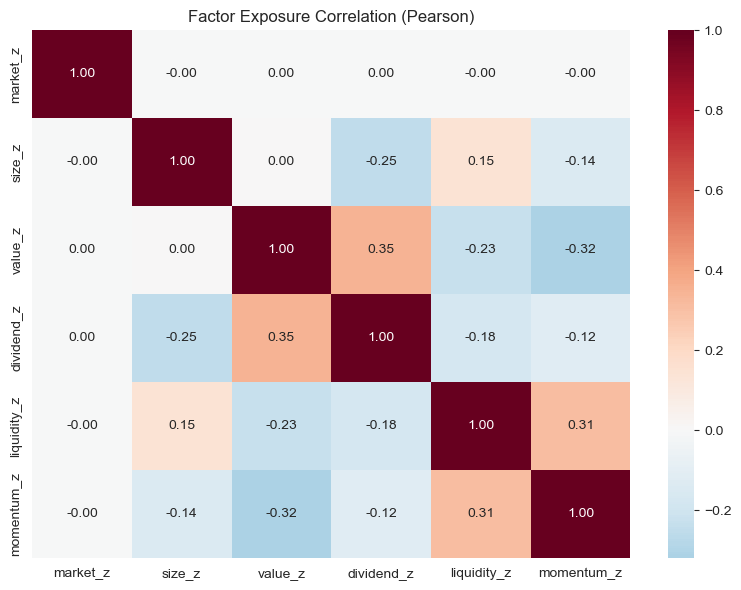

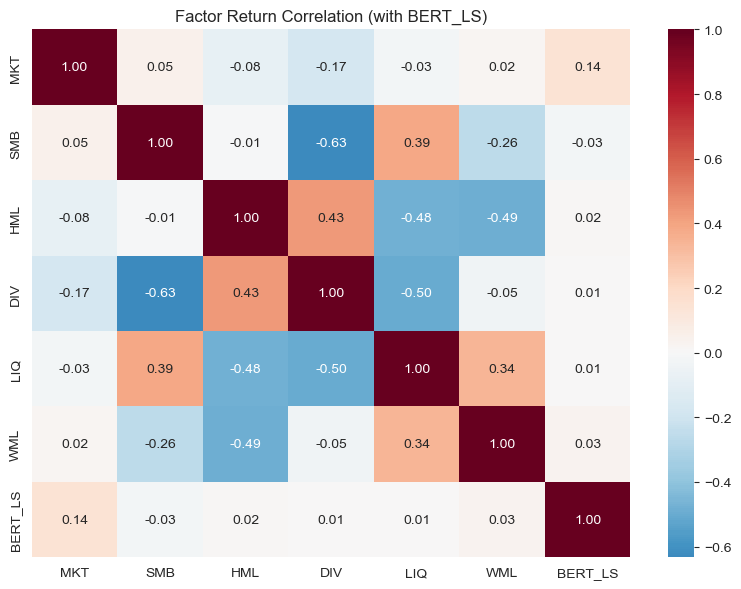

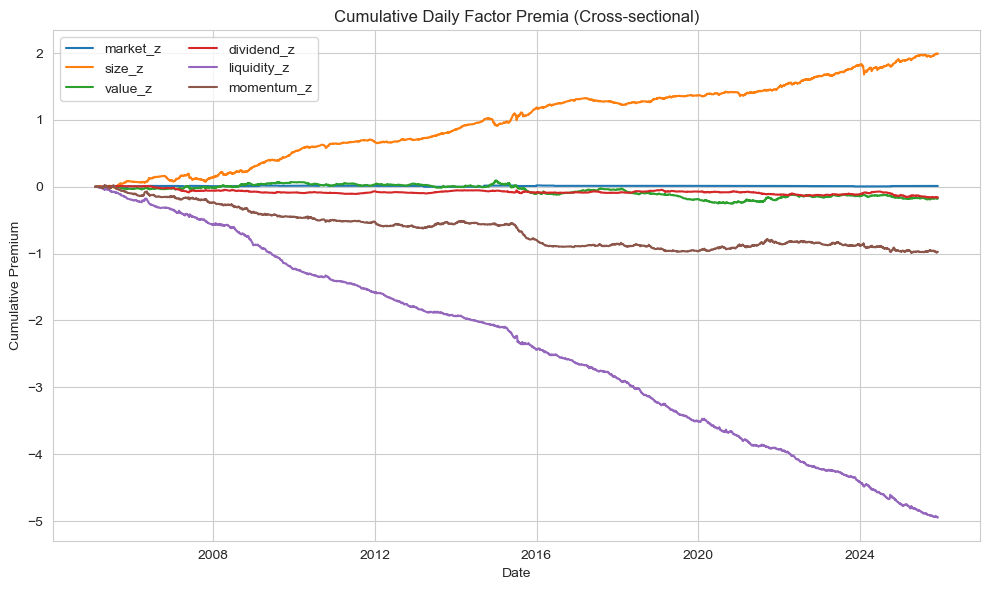

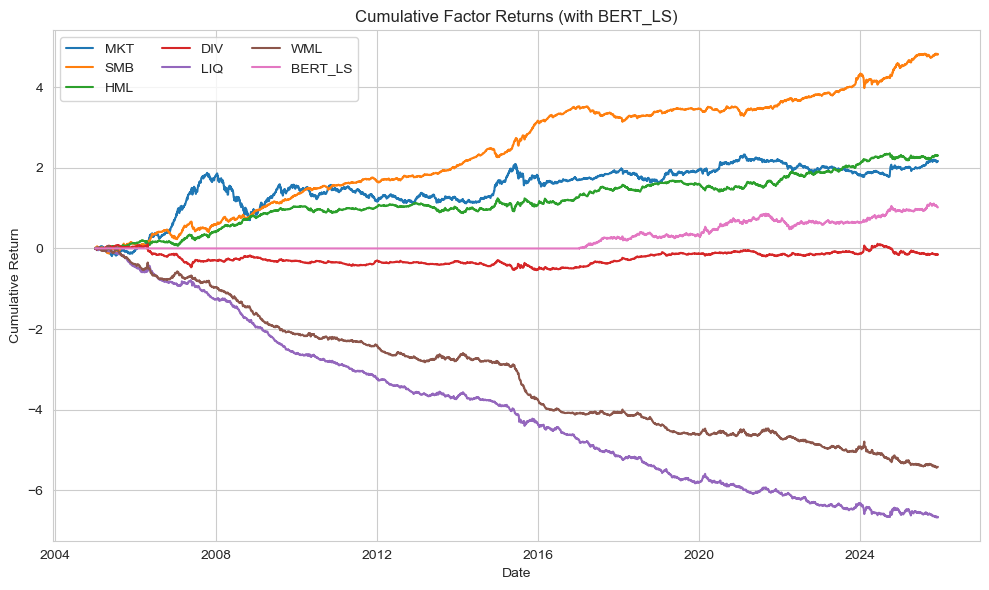

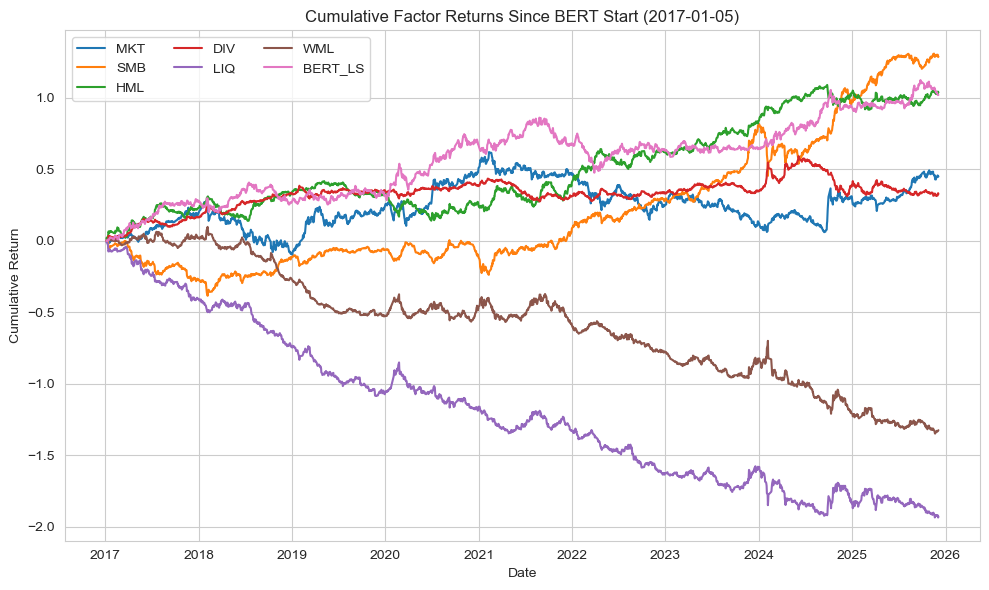

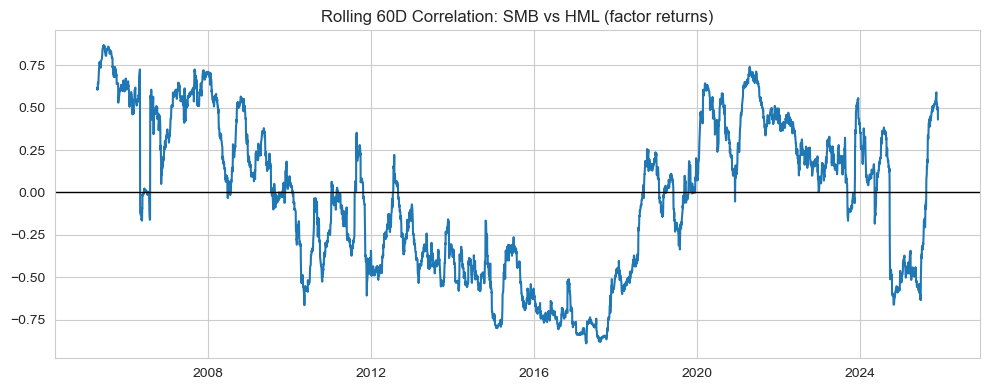

In [64]:
import math

# 修正 premia_summary 里的 p 值计算
if 'premia_df' in globals() and len(premia_df) > 0:
    summary_rows = []
    for c in ['alpha'] + factor_cols:
        s = pd.to_numeric(premia_df[c], errors='coerce').dropna()
        if len(s) < 3:
            continue
        mean_val = s.mean()
        std_val = s.std(ddof=1)
        t_stat = mean_val / (std_val / np.sqrt(len(s))) if std_val > 0 else np.nan
        p_val = math.erfc(abs(t_stat) / math.sqrt(2)) if pd.notna(t_stat) else np.nan
        summary_rows.append({
            'term': c,
            'n_periods': len(s),
            'mean_premium': mean_val,
            'std_premium': std_val,
            't_stat': t_stat,
            'p_value': p_val,
        })
    premia_summary = pd.DataFrame(summary_rows).sort_values('term').reset_index(drop=True)

# 暴露相关性（截面暴露）
exposure_corr_pearson = model_df[factor_cols].corr(method='pearson')
exposure_corr_spearman = model_df[factor_cols].corr(method='spearman')

# 截面回归得到的风险溢价相关性
premia_cols = [c for c in factor_cols if c in premia_df.columns]
premia_corr = premia_df[premia_cols].corr(method='pearson') if len(premia_df) else pd.DataFrame()

# 因子收益相关性（含 BERT long-short）
factor_return_cols = [c for c in ['MKT', 'SMB', 'HML', 'DIV', 'LIQ', 'WML', 'BERT_LS'] if c in factor_ret_df.columns]
factor_return_corr = factor_ret_df[factor_return_cols].corr(method='pearson') if len(factor_return_cols) else pd.DataFrame()

print('Exposure Pearson corr:')
print(exposure_corr_pearson)
print('\nPremia corr:')
print(premia_corr)
print('\nFactor return corr (with BERT_LS):')
print(factor_return_corr)

# 图 1：暴露相关性热力图
plt.figure(figsize=(8, 6))
sns.heatmap(exposure_corr_pearson, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Factor Exposure Correlation (Pearson)')
plt.tight_layout()
plt.show()

# 图 2：因子收益相关性热力图（含 BERT_LS）
if len(factor_return_corr):
    plt.figure(figsize=(8, 6))
    sns.heatmap(factor_return_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
    plt.title('Factor Return Correlation (with BERT_LS)')
    plt.tight_layout()
    plt.show()

# 图 3：因子风险溢价累计曲线（截面回归）
if len(premia_df):
    plt.figure(figsize=(10, 6))
    for c in factor_cols:
        if c in premia_df.columns:
            plt.plot(premia_df['trade_date'], premia_df[c].fillna(0).cumsum(), label=c)
    plt.legend(ncol=2)
    plt.title('Cumulative Daily Factor Premia (Cross-sectional)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Premium')
    plt.tight_layout()
    plt.show()

# 图 4：因子收益累计曲线（含 BERT_LS）
if len(factor_return_cols):
    plt.figure(figsize=(10, 6))
    for c in factor_return_cols:
        plt.plot(factor_ret_df['trade_date'], factor_ret_df[c].fillna(0).cumsum(), label=c)
    plt.legend(ncol=3)
    plt.title('Cumulative Factor Returns (with BERT_LS)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.tight_layout()
    plt.show()

# 图 4b：从 BERT 策略起始日开始的因子收益累计曲线
if len(factor_return_cols) and ('BERT_LS' in factor_ret_df.columns):
    bert_start_date = factor_ret_df.loc[factor_ret_df['BERT_LS'].notna(), 'trade_date'].min()
    if pd.notna(bert_start_date):
        factor_ret_from_bert = factor_ret_df.loc[factor_ret_df['trade_date'] >= bert_start_date].copy()
        plt.figure(figsize=(10, 6))
        for c in factor_return_cols:
            plt.plot(
                factor_ret_from_bert['trade_date'],
                factor_ret_from_bert[c].fillna(0).cumsum(),
                label=c
            )
        plt.legend(ncol=3)
        plt.title(f'Cumulative Factor Returns Since BERT Start ({bert_start_date.date()})')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.tight_layout()
        plt.show()

# 图 5：滚动相关性（示例：SMB vs HML, 60日）
if len(factor_ret_df) >= 60 and {'SMB', 'HML'}.issubset(set(factor_ret_df.columns)):
    roll_corr = factor_ret_df['SMB'].rolling(60).corr(factor_ret_df['HML'])
    plt.figure(figsize=(10, 4))
    plt.plot(factor_ret_df['trade_date'], roll_corr)
    plt.axhline(0, color='black', lw=1)
    plt.title('Rolling 60D Correlation: SMB vs HML (factor returns)')
    plt.tight_layout()
    plt.show()

## 12) 结果汇总与导出

导出以下结果文件：
- `factor_premia_daily.csv`
- `factor_premia_summary.csv`
- `factor_exposure_corr.csv`
- `factor_premia_corr.csv`
- `factor_exposure_corr_spearman.csv`
- `factor_return_daily_with_bert.csv`
- `factor_return_corr_with_bert.csv`
- `time_series_regression_summary.csv`

In [62]:
premia_df.to_csv('factor_premia_daily.csv', index=False, encoding='utf-8-sig')
premia_summary.to_csv('factor_premia_summary.csv', index=False, encoding='utf-8-sig')
exposure_corr_pearson.to_csv('factor_exposure_corr.csv', encoding='utf-8-sig')
exposure_corr_spearman.to_csv('factor_exposure_corr_spearman.csv', encoding='utf-8-sig')
premia_corr.to_csv('factor_premia_corr.csv', encoding='utf-8-sig')
factor_ret_df.to_csv('factor_return_daily_with_bert.csv', index=False, encoding='utf-8-sig')
factor_return_corr.to_csv('factor_return_corr_with_bert.csv', encoding='utf-8-sig')
ts_summary.to_csv('time_series_regression_summary.csv', index=False, encoding='utf-8-sig')

print('导出完成。')
print('premia_df:', premia_df.shape)
print('premia_summary:', premia_summary.shape)
print('exposure_corr_pearson:', exposure_corr_pearson.shape)
print('premia_corr:', premia_corr.shape)
print('factor_ret_df:', factor_ret_df.shape)
print('factor_return_corr:', factor_return_corr.shape)
print('ts_summary:', ts_summary.shape)

导出完成。
premia_df: (4327, 24)
premia_summary: (7, 6)
exposure_corr_pearson: (6, 6)
premia_corr: (6, 6)
factor_ret_df: (5082, 8)
factor_return_corr: (7, 7)
ts_summary: (5, 19)


## 结果解读与注意事项

- 若某些因子在 `factor_premia_summary.csv` 中的 `t_stat` 绝对值较高（通常 > 2），说明样本期内该因子风险溢价更稳定。
- 若 `factor_exposure_corr.csv` 或 `factor_premia_corr.csv` 中出现高相关（如绝对值 > 0.7），需警惕多重共线性。
- 本示例将 $R_f$ 近似为 0；如有无风险利率数据，建议替换为真实 $R_f$ 以得到更标准的超额收益模型。
- 动量因子当前为 1 月（20 日）、3 月（60 日）、12 月（240 日）动量的等权平均，并跳过最近 1 日。
- 股票池当前为全市场股票，但剔除上市后 1 个月内样本；指数因子（000300.SH）不受该过滤影响。
- 回归前的分位数截尾与 z-score 会影响系数量纲与稳健性，可根据研究口径切换为 MAD 去极值。

In [63]:
# 诊断 WML 异常跳点
suspect_dates = pd.to_datetime(['2015-03-19', '2015-04-02', '2016-05-31'])
for dt in suspect_dates:
    g = model_df.loc[model_df['trade_date'] == dt, ['stock_code', 'momentum_z', 'next_ret']].dropna()
    if len(g) < 30:
        print(dt.date(), 'insufficient obs:', len(g))
        continue
    low_cut = g['momentum_z'].quantile(0.3)
    high_cut = g['momentum_z'].quantile(0.7)
    hi = g.loc[g['momentum_z'] >= high_cut, 'next_ret']
    lo = g.loc[g['momentum_z'] <= low_cut, 'next_ret']
    wml = hi.mean() - lo.mean()
    print('\nDate:', dt.date(), 'n=', len(g), 'WML=', round(wml, 6))
    print('  high group n=', len(hi), 'mean=', round(hi.mean(), 6), 'min=', round(hi.min(), 6), 'max=', round(hi.max(), 6))
    print('  low  group n=', len(lo), 'mean=', round(lo.mean(), 6), 'min=', round(lo.min(), 6), 'max=', round(lo.max(), 6))
    print('  top abs next_ret stocks:')
    top_abs = g.assign(absret=g['next_ret'].abs()).sort_values('absret', ascending=False).head(10)
    print(top_abs[['stock_code','momentum_z','next_ret']].to_string(index=False))


Date: 2015-03-19 n= 2081 WML= 0.00703
  high group n= 625 mean= 0.01608 min= -0.0425 max= 0.1003
  low  group n= 625 mean= 0.00905 min= -0.1004 max= 0.1006
  top abs next_ret stocks:
stock_code  momentum_z  next_ret
    600193   -0.763084    0.1006
    002641   -0.556173    0.1004
    000766   -0.657430   -0.1004
    600979   -0.228066    0.1004
    600469    0.926097    0.1003
    002416   -0.697533    0.1003
    000573   -0.342163    0.1003
    600337    0.164684    0.1002
    600714   -0.338292    0.1002
    600804    0.375372    0.1002

Date: 2015-04-02 n= 2084 WML= 0.004103
  high group n= 625 mean= 0.0248 min= -0.0561 max= 0.1006
  low  group n= 625 mean= 0.020697 min= -0.0328 max= 0.1005
  top abs next_ret stocks:
stock_code  momentum_z  next_ret
    000709   -0.005163    0.1009
    600397    0.266876    0.1006
    600854   -0.671165    0.1005
    002122    0.301684    0.1005
    600234    0.970663    0.1004
    002006   -0.172678    0.1004
    000868    0.247288    0.1004
    